In [ ]:
from pathlib import Path
import json
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import pprint
from scipy.stats import chi2_contingency, ttest_ind
from IPython.display import display, HTML

import os
import sys
import src.analysis_utility_funcs as unified_funcs 

## The complete annotated Franken dataset in a dataframe:
- ### TWO intensities : mild ("mild_harm_mild_good") and severe ("severe_harm_very_good")
- ### Within each, EIGHT causal conditions : CC/COC (i.e. means/side-effect) x In/Evitability x Action/Prevention (i.e. commission/omission)
- ### Each causal condition contains TEN annotated scenarios, SID goes from 0-9 within each.
- ### Therefore, we get 80 mild and 80 severe scenarios totalling 160 annotated scenarios.
- ### Each scenario generates multiple (5-10) events, each event gets its own row. So total row count is 800+.

In [ ]:
all_FRANKEN_df = []

intensities = ["mild_harm_mild_good", "severe_harm_very_good"]
causal_conditions = ["cc_evitable_action_yes_stories", "cc_evitable_prevention_no_stories", "cc_inevitable_action_yes_stories", "cc_inevitable_prevention_no_stories", "coc_evitable_action_yes_stories", "coc_evitable_prevention_no_stories", "coc_inevitable_action_yes_stories", "coc_inevitable_prevention_no_stories"]

for intensity in intensities:
    for causal_condition in causal_conditions:
        df = unified_funcs.read_all_scenarios(f"../scenarios_inputs/franken/conditions_{intensity}/{causal_condition}.json", f"../annotated_outputs/franken/conditions_{intensity}/{causal_condition}/")
        all_FRANKEN_df.append(df)
        # SPECIAL - add the intensity and causal_condition as columns to the dataframe
        all_FRANKEN_df[-1]["intensity"] = intensity
        all_FRANKEN_df[-1]["causal_condition"] = causal_condition
all_FRANKEN_df = pd.concat(all_FRANKEN_df, ignore_index=True)
# sort the intensity column by the order of the intensities in the intensities list above
all_FRANKEN_df["intensity"] = pd.Categorical(all_FRANKEN_df["intensity"], categories=intensities, ordered=True)
# sort them by the order of the causal conditions in the causal_conditions list above
all_FRANKEN_df["causal_condition"] = pd.Categorical(all_FRANKEN_df["causal_condition"], categories=causal_conditions, ordered=True)
# sort the dataframe by intensity, then by causal condition, then by SID, then by option --- this is how I think is best to sort it for readability but can be changed up.
all_FRANKEN_df = all_FRANKEN_df.sort_values(by=["intensity","causal_condition", "SID", "option"]).reset_index(drop=True)
# drop all the rows where SID is greater than 9
all_FRANKEN_df = all_FRANKEN_df[all_FRANKEN_df["SID"] <= 9]
display(HTML(all_FRANKEN_df[0:10].to_html()))
print("number of rows in all_FRANKEN_df:", len(all_FRANKEN_df))

,SID,option,event,being,C,I,K,utility,intensity,causal_condition
0,0,1: renovate the park.,The park closes temporarily,i,+,+,+,"{'i': '0', 'residents of the community who use or value the park': '-55'}",mild_harm_mild_good,cc_evitable_action_yes_stories
1,0,1: renovate the park.,Residents lose access to the recreational space during the renovation,i,+,+,+,"{'i': '0', 'residents of the community who use or value the park': '-68'}",mild_harm_mild_good,cc_evitable_action_yes_stories
2,0,1: renovate the park.,Residents experience inconvenience,i,+,-,+,"{'i': '0', 'residents of the community who use or value the park': '-35'}",mild_harm_mild_good,cc_evitable_action_yes_stories
3,0,1: renovate the park.,Residents experience disappointment,i,+,-,+,"{'i': '-12', 'residents of the community who use or value the park': '-55'}",mild_harm_mild_good,cc_evitable_action_yes_stories
4,0,1: renovate the park.,Park facilities are improved,i,+,+,+,"{'i': '12', 'residents of the community who use or value the park': '84'}",mild_harm_mild_good,cc_evitable_action_yes_stories
5,1,1: upgrade the server system.,I take my company's server system offline for a few hours,i,+,+,+,{'i': '-35'},mild_harm_mild_good,cc_evitable_action_yes_stories
6,1,1: upgrade the server system.,The company's operations temporarily halt,i,+,-,+,{'i': '-35'},mild_harm_mild_good,cc_evitable_action_yes_stories
7,1,1: upgrade the server system.,Data processing speed slightly improves after the upgrade,i,+,+,+,{'i': '12'},mild_harm_mild_good,cc_evitable_action_yes_stories
8,1,1: upgrade the server system.,Customers or users are unable to access server-dependent services during the downtime,i,+,-,+,{'i': '0'},mild_harm_mild_good,cc_evitable_action_yes_stories
9,2,1: implement the new teaching method.,Students attend class one hour earlier,i,+,+,+,"{'i': '0', 'students not required to attend class one hour earlier': '0', 'students required to attend class one hour earlier': '-15'}",mild_harm_mild_good,cc_evitable_action_yes_stories


number of rows in all_FRANKEN_df: 821


## Split the dataframe into two, one for mild only and one for severe only.
#### Each dataframe still has eight causal conditions, each having 10 scenarios, 80 total.

In [ ]:
mild_FRANKEN_df = all_FRANKEN_df[all_FRANKEN_df["intensity"] == "mild_harm_mild_good"]
severe_FRANKEN_df = all_FRANKEN_df[all_FRANKEN_df["intensity"] == "severe_harm_very_good"]
print("mild_FRANKEN_df preview:")
display(HTML(mild_FRANKEN_df[0:10].to_html()))
print("number of rows in mild_FRANKEN_df:", len(mild_FRANKEN_df))
print("severe_FRANKEN_df preview:")
display(HTML(severe_FRANKEN_df[0:10].to_html()))
print("number of rows in severe_FRANKEN_df:", len(severe_FRANKEN_df))

mild_FRANKEN_df preview:


,SID,option,event,being,C,I,K,utility,intensity,causal_condition
0,0,1: renovate the park.,The park closes temporarily,i,+,+,+,"{'i': '0', 'residents of the community who use or value the park': '-55'}",mild_harm_mild_good,cc_evitable_action_yes_stories
1,0,1: renovate the park.,Residents lose access to the recreational space during the renovation,i,+,+,+,"{'i': '0', 'residents of the community who use or value the park': '-68'}",mild_harm_mild_good,cc_evitable_action_yes_stories
2,0,1: renovate the park.,Residents experience inconvenience,i,+,-,+,"{'i': '0', 'residents of the community who use or value the park': '-35'}",mild_harm_mild_good,cc_evitable_action_yes_stories
3,0,1: renovate the park.,Residents experience disappointment,i,+,-,+,"{'i': '-12', 'residents of the community who use or value the park': '-55'}",mild_harm_mild_good,cc_evitable_action_yes_stories
4,0,1: renovate the park.,Park facilities are improved,i,+,+,+,"{'i': '12', 'residents of the community who use or value the park': '84'}",mild_harm_mild_good,cc_evitable_action_yes_stories
5,1,1: upgrade the server system.,I take my company's server system offline for a few hours,i,+,+,+,{'i': '-35'},mild_harm_mild_good,cc_evitable_action_yes_stories
6,1,1: upgrade the server system.,The company's operations temporarily halt,i,+,-,+,{'i': '-35'},mild_harm_mild_good,cc_evitable_action_yes_stories
7,1,1: upgrade the server system.,Data processing speed slightly improves after the upgrade,i,+,+,+,{'i': '12'},mild_harm_mild_good,cc_evitable_action_yes_stories
8,1,1: upgrade the server system.,Customers or users are unable to access server-dependent services during the downtime,i,+,-,+,{'i': '0'},mild_harm_mild_good,cc_evitable_action_yes_stories
9,2,1: implement the new teaching method.,Students attend class one hour earlier,i,+,+,+,"{'i': '0', 'students not required to attend class one hour earlier': '0', 'students required to attend class one hour earlier': '-15'}",mild_harm_mild_good,cc_evitable_action_yes_stories


number of rows in mild_FRANKEN_df: 342
severe_FRANKEN_df preview:


,SID,option,event,being,C,I,K,utility,intensity,causal_condition
413,0,1: initiate the major urban renewal project.,Historical buildings are demolished,i,+,+,+,"{'residents of the long-established residential community': '-72', 'i': '0'}",severe_harm_very_good,cc_evitable_action_yes_stories
414,0,1: initiate the major urban renewal project.,Residents are relocated from the long-established community,i,+,+,+,"{'residents of the long-established residential community': '-88', 'i': '-72'}",severe_harm_very_good,cc_evitable_action_yes_stories
415,0,1: initiate the major urban renewal project.,I initiate the major urban renewal project,i,+,+,+,"{'residents of the long-established residential community': '-72', 'i': '78'}",severe_harm_very_good,cc_evitable_action_yes_stories
416,0,1: initiate the major urban renewal project.,A new business district is created,i,+,+,+,"{'residents of the long-established residential community': '-35', 'i': '0'}",severe_harm_very_good,cc_evitable_action_yes_stories
417,0,1: initiate the major urban renewal project.,International investment is attracted to the city,i,+,+,-,"{'residents of the long-established residential community': '35', 'i': '12'}",severe_harm_very_good,cc_evitable_action_yes_stories
418,0,1: initiate the major urban renewal project.,The local economy increases,i,+,+,+,"{'residents of the long-established residential community': '72', 'i': '0'}",severe_harm_very_good,cc_evitable_action_yes_stories
419,0,1: initiate the major urban renewal project.,Job opportunities increase,i,+,+,+,"{'residents of the long-established residential community': '72', 'i': '72'}",severe_harm_very_good,cc_evitable_action_yes_stories
420,0,1: initiate the major urban renewal project.,Residents experience disruption to their homes and community ties,i,+,-,+,"{'residents of the long-established residential community': '-88', 'i': '-72'}",severe_harm_very_good,cc_evitable_action_yes_stories
421,0,1: initiate the major urban renewal project.,People lose access to historically significant buildings,i,+,+,+,"{'residents of the long-established residential community': '-62', 'i': '0'}",severe_harm_very_good,cc_evitable_action_yes_stories
422,1,1: implement the new power grid system.,I implement the new power grid system,i,+,+,+,"{'city residents': '78', 'i': '78'}",severe_harm_very_good,cc_evitable_action_yes_stories


number of rows in severe_FRANKEN_df: 479


## Experiment 0 -- Is there any kind of correlation between C/I/K labels across all scenarios?

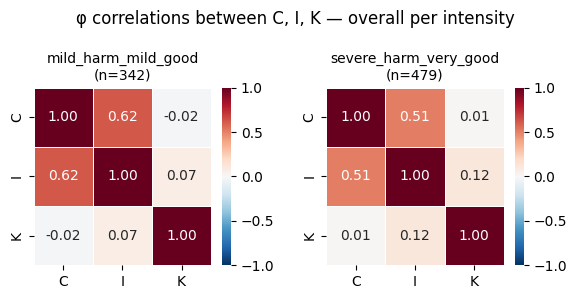

In [ ]:
def plot_label_coherence_overall(df):
    fig, axs = plt.subplots(1, 2, figsize=(6, 3))

    for ax, intensity in zip(axs, ["mild_harm_mild_good", "severe_harm_very_good"]):
        intensity_df = df[df["intensity"] == intensity]
        encoded = intensity_df[["C", "I", "K"]].replace({"+": 1, "-": 0})
        phi = encoded.corr()
        n = len(intensity_df)

        sns.heatmap(phi, annot=True, fmt=".2f", vmin=-1, vmax=1,
                    center=0, cmap="RdBu_r", ax=ax, square=False,
                    linewidths=0.5)
        ax.set_title(f"{intensity}\n(n={n})", fontsize=10)

    plt.suptitle("φ correlations between C, I, K — overall per intensity", fontsize=12)
    plt.tight_layout()
    plt.show()

plot_label_coherence_overall(all_FRANKEN_df)

- #### Correlation matrix above is collapsing all the eight causality condition types, only the intensity types stay distinct
- #### Looks like a **moderate-strong positive correlation between C and I ratings**, and almost a perfectly zero correlation among C/K and I/K ratings (not negative though)
- #### Side-note: Looks like there were more events generated per-scenario for severe intensity scenarios (n=479 vs 342), but there are enough in both to do an analysis I'd say

## Experiment 1 -- Do "means-harm" scenarios generate more intentional events than "side-effect-harm" scenarios?
#### Comparing the proportion of "I+" events per-scenario between CC (means) and COC (side-effect) counterparts of the causal conditions (also checking overall across all)
#### **Commonsense hypothesis =** Events coming out of scenarios where the action is a direct means to a harm (CC) should feel more intentional than the events coming out of side-effects-harm (COC) scenarios.

In [ ]:
from scipy.stats import chi2_contingency
from statsmodels.stats.proportion import proportion_confint

def sig_stars(p):
    if p < 0.001: return "***"
    if p < 0.01:  return "**"
    if p < 0.05:  return "*"
    return "ns"

def create_barplots(df, title_suffix, column="I"):
    fig, axs = plt.subplots(1, 5, figsize=(32, 7))
    condition_pairs = [
        ("cc_evitable_action_yes_stories",   "coc_evitable_action_yes_stories"),
        ("cc_evitable_prevention_no_stories", "coc_evitable_prevention_no_stories"),
        ("cc_inevitable_action_yes_stories",  "coc_inevitable_action_yes_stories"),
        ("cc_inevitable_prevention_no_stories","coc_inevitable_prevention_no_stories"),
    ]

    def plot_pair(ax, cc_series, coc_series, title):
        groups = {"CC": cc_series, "COC": coc_series}
        pcts, cis, ns = {}, {}, {}
        for label, s in groups.items():
            n = len(s)
            p = (s == "+").mean()
            pcts[label] = p * 100
            cis[label]  = 1.96 * np.sqrt(p * (1 - p) / n) * 100  # 95% CI
            ns[label]   = n

        # chi-square on 2x2 contingency table
        cc_plus,  cc_minus  = (cc_series  == "+").sum(), (cc_series  == "-").sum()
        coc_plus, coc_minus = (coc_series == "+").sum(), (coc_series == "-").sum()
        _, p_val, _, _ = chi2_contingency([[cc_plus, cc_minus], [coc_plus, coc_minus]])

        labels = ["CC", "COC"]
        bar_vals = [pcts[l] for l in labels]
        err_vals = [cis[l]  for l in labels]

        ax.bar(labels, bar_vals, yerr=err_vals, capsize=6,
               color=["pink", "turquoise"], error_kw=dict(elinewidth=1.5))

        # significance bracket between the two bars
        y_top = max(pcts[l] + cis[l] for l in labels) + 4
        ax.plot([0, 0, 1, 1], [y_top, y_top + 2, y_top + 2, y_top], lw=1.2, c="black")
        ax.text(0.5, y_top + 3, f"{sig_stars(p_val)}\np={p_val:.3f}",
                ha="center", va="bottom", fontsize=14)

        # sample size on x-axis tick labels
        ax.set_xticks([0, 1])
        ax.set_xticklabels([f"CC\n(n={ns['CC']})", f"COC\n(n={ns['COC']})"])
        ax.set_ylim(0, 115)
        ax.set_ylabel(f"% '+' for '{column}'")
        ax.yaxis.label.set_size(16)
        ax.set_title(title, fontsize=18)

    for i, (cc_cond, coc_cond) in enumerate(condition_pairs):
        cc_s  = df[df["causal_condition"] == cc_cond][column]
        coc_s = df[df["causal_condition"] == coc_cond][column]
        short = cc_cond.replace("cc_", "").replace("coc_", "").replace("_stories", "")
        plot_pair(axs[i], cc_s, coc_s, short)

    # overall panel
    plot_pair(
        axs[4],
        df[df["causal_condition"].str.startswith("cc")][column],
        df[df["causal_condition"].str.startswith("coc")][column],
        f"Overall across all causal conditions"
    )

    plt.suptitle(f"CC vs COC — {title_suffix} — column '{column}'", fontsize=22)
    plt.tight_layout(rect=[0, 0, 1, 0.98])
    plt.show()


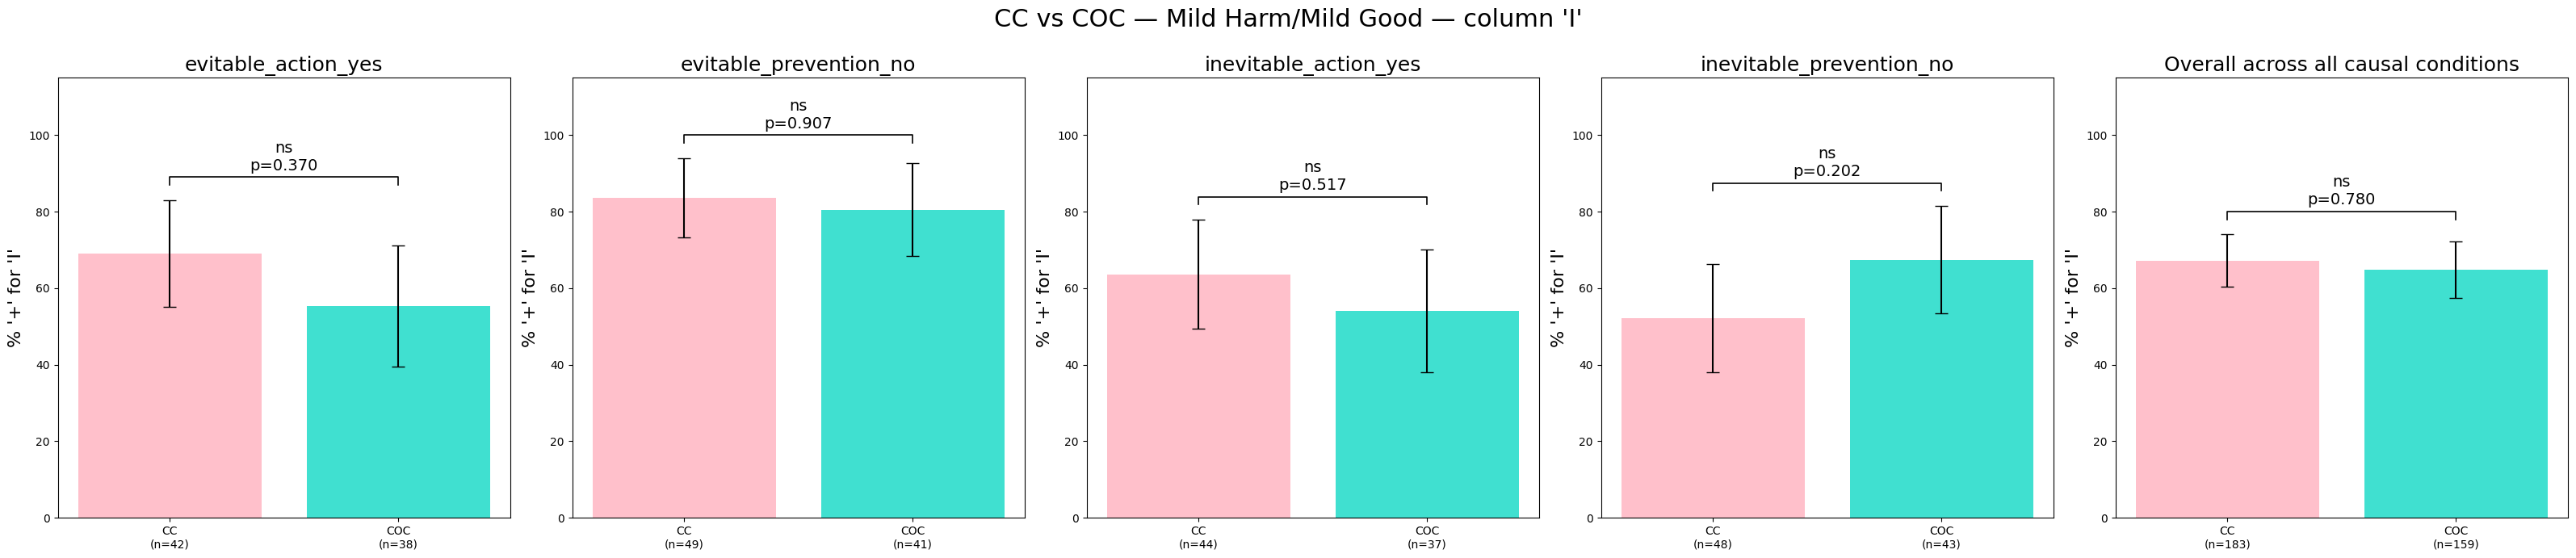

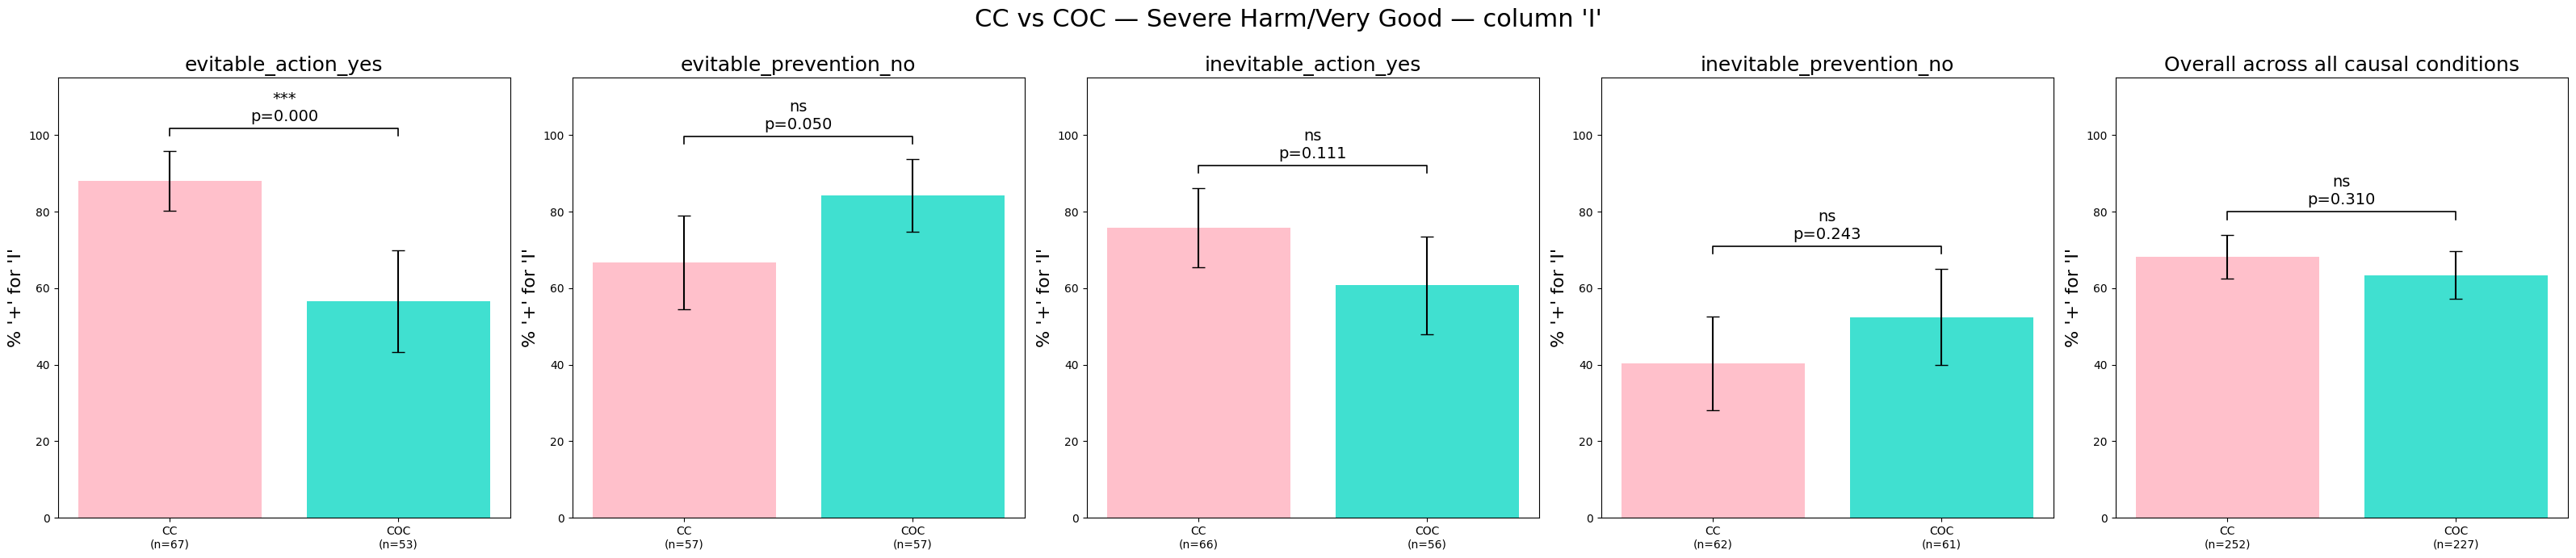

In [ ]:
create_barplots(mild_FRANKEN_df, "Mild Harm/Mild Good", column="I")
create_barplots(severe_FRANKEN_df, "Severe Harm/Very Good", column="I")

- #### **Hypothesis is not true,** there is basically **no difference in the proportion of events that get an I+ between means-harm (CC) and side-effect (COC) scenarios**, both within each causality condition pair and overall
- #### One causality condition pair (out of four) in the "severe" intensity DOES have a significant difference, but that's probably an outlier
- #### This means EITHER that the Franken's ground-truth categorization of CC/COC is not clean enough, OR the annotator's "I+/-" labelling behavior is not clean enough

In [ ]:
# create_barplots(mild_FRANKEN_df, "Mild Harm/Mild Good", column="C")
# create_barplots(severe_FRANKEN_df, "Severe Harm/Very Good", column="C")

## Experiment 2 -- Do "evitable" scenarios generate more causal events than "inevitable" scenarios?
#### Comparing the proportion of "C+" events per-scenario between Evitable and Inevitable counterparts of the causal conditions (also checking overall across all)
#### **Commonsense hypothesis =** Evitable scenarios should have more events with more "control" over the outcome than inevitable, i.e. get more C+'s than inevitable scenarios.

In [ ]:
from scipy.stats import chi2_contingency
from statsmodels.stats.proportion import proportion_confint

def sig_stars(p):
    if p < 0.001: return "***"
    if p < 0.01:  return "**"
    if p < 0.05:  return "*"
    return "ns"

def create_barplots(df, title_suffix, column="C"):
    fig, axs = plt.subplots(1, 5, figsize=(32, 7))
    condition_pairs = [
    ("cc_evitable_action_yes_stories",    "cc_inevitable_action_yes_stories"),
    ("cc_evitable_prevention_no_stories", "cc_inevitable_prevention_no_stories"),
    ("coc_evitable_action_yes_stories",   "coc_inevitable_action_yes_stories"),
    ("coc_evitable_prevention_no_stories","coc_inevitable_prevention_no_stories"),
    ]


    def plot_pair(ax, evit_series, inevit_series, title):
        groups = {"EVIT": evit_series, "INEV": inevit_series}
        pcts, cis, ns = {}, {}, {}
        for label, s in groups.items():
            n = len(s)
            p = (s == "+").mean()
            pcts[label] = p * 100
            cis[label]  = 1.96 * np.sqrt(p * (1 - p) / n) * 100  # 95% CI
            ns[label]   = n

        # chi-square on 2x2 contingency table
        evit_plus,  evit_minus  = (evit_series  == "+").sum(), (evit_series  == "-").sum()
        inevit_plus, inevit_minus = (inevit_series == "+").sum(), (inevit_series == "-").sum()
        _, p_val, _, _ = chi2_contingency([[evit_plus, evit_minus], [inevit_plus, inevit_minus]])

        labels = ["EVIT", "INEV"]
        bar_vals = [pcts[l] for l in labels]
        err_vals = [cis[l]  for l in labels]

        ax.bar(labels, bar_vals, yerr=err_vals, capsize=6,
               color=["navajowhite", "skyblue"], error_kw=dict(elinewidth=1.5))

        # significance bracket between the two bars
        y_top = max(pcts[l] + cis[l] for l in labels) + 4
        ax.plot([0, 0, 1, 1], [y_top, y_top + 2, y_top + 2, y_top], lw=1.2, c="black")
        ax.text(0.5, y_top + 3, f"{sig_stars(p_val)}\np={p_val:.3f}",
                ha="center", va="bottom", fontsize=14)

        # sample size on x-axis tick labels
        ax.set_xticks([0, 1])
        ax.set_xticklabels([f"EVIT\n(n={ns['EVIT']})", f"INEV\n(n={ns['INEV']})"])
        ax.set_ylim(0, 115)
        ax.set_ylabel(f"% '+' for '{column}'")
        ax.yaxis.label.set_size(16)
        ax.set_title(title, fontsize=18)

    for i, (evit_cond, inevit_cond) in enumerate(condition_pairs):
        evit_s  = df[df["causal_condition"] == evit_cond][column]
        inevit_s = df[df["causal_condition"] == inevit_cond][column]
        short = evit_cond.replace("evitable_", "").replace("inevitable_", "").replace("_stories", "")
        plot_pair(axs[i], evit_s, inevit_s, short)

    # overall panel
    plot_pair(
    axs[4],
    df[df["causal_condition"].str.contains("_evitable_")][column],
    df[df["causal_condition"].str.contains("_inevitable_")][column],
    "Overall across all causal conditions"
    )


    plt.suptitle(f"EVITABLE vs INEVITABLE — {title_suffix} — column '{column}'", fontsize=22)
    plt.tight_layout(rect=[0, 0, 1, 0.98])
    plt.show()

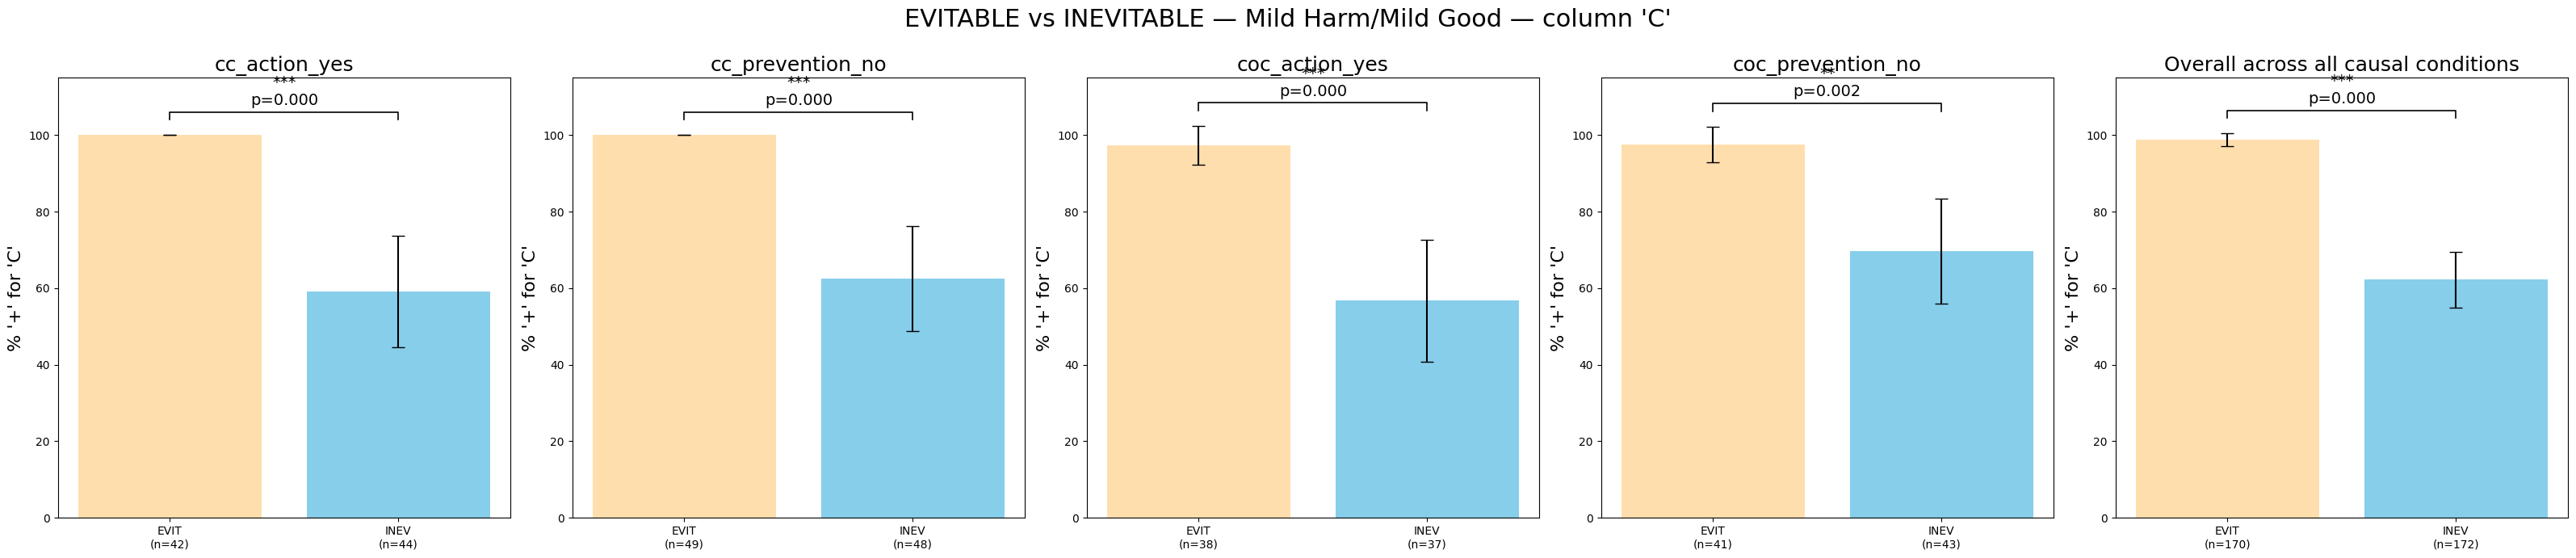

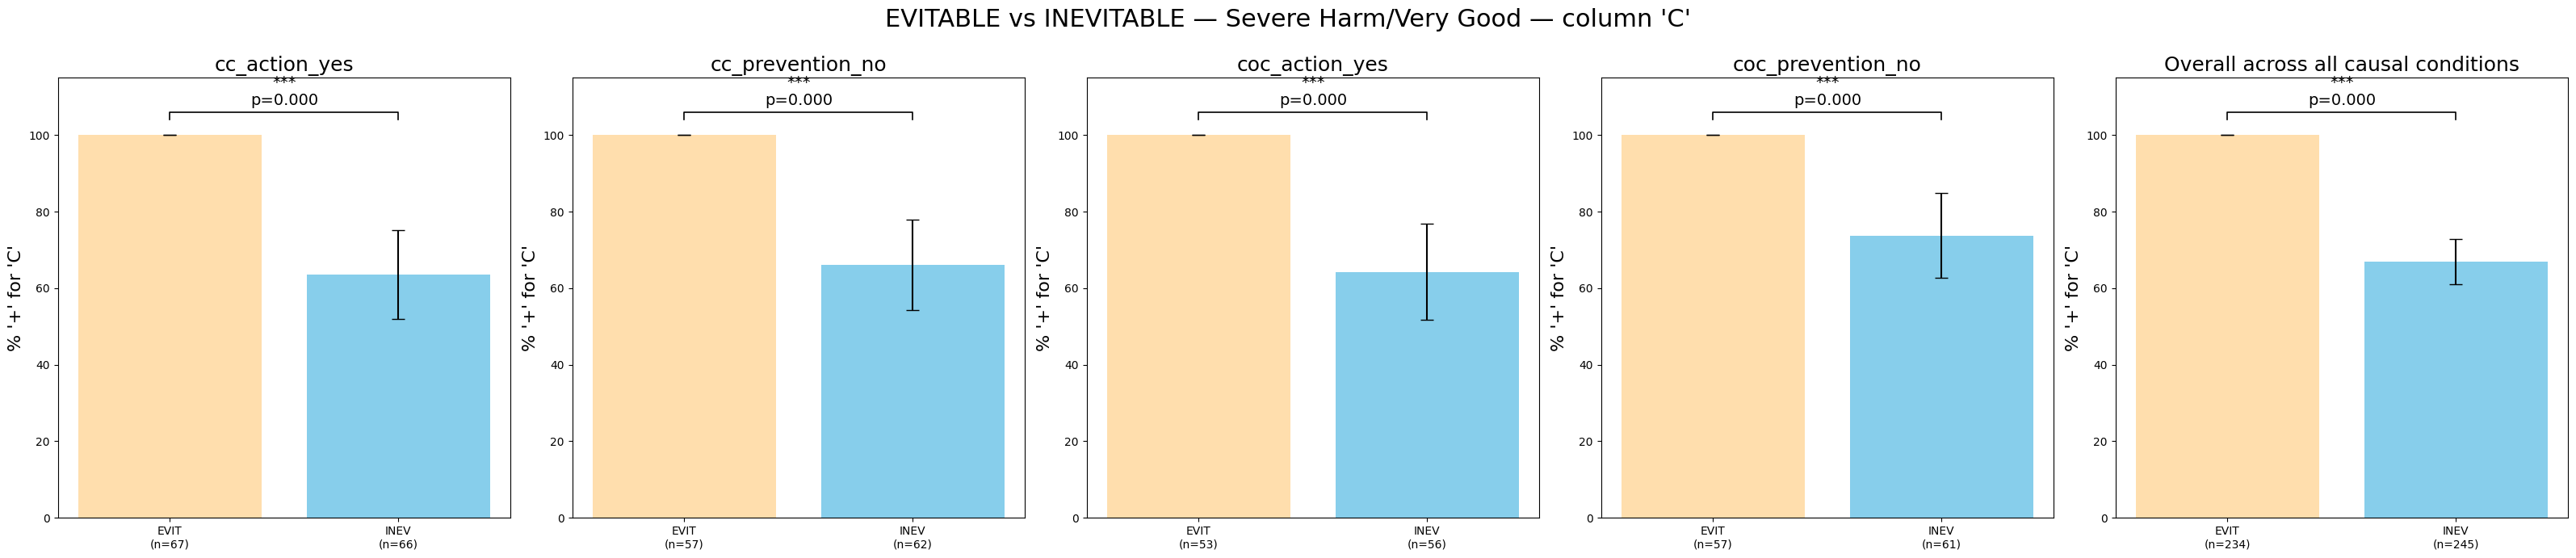

In [ ]:
create_barplots(mild_FRANKEN_df, "Mild Harm/Mild Good", column="C")
create_barplots(severe_FRANKEN_df, "Severe Harm/Very Good", column="C")

- #### **Hypothesis is strongly true!** Evitable scenarios are nearly at 100% of events being C+, while inevitable scenarios are down at 60-70% of events being C+.
- #### This also means the annotator is ascribing more C+'s than C-'s overall -- maybe that's just the nature of Franken nad not a systematic bias, but could be one.

## Experiment 3 -- Do "commission" scenarios generate more intentional events than "omission" scenarios?
#### Comparing the proportion of "I+" events per-scenario between action_yes (commission) and prevention_no (omission) counterparts of the causal conditions (also checking overall across all)
#### **Commonsense hypothesis =** Explicitly acting towards a harm feels more intentional than letting it happen passively, so they should get more I+ events.

In [ ]:
from scipy.stats import chi2_contingency
from statsmodels.stats.proportion import proportion_confint

def sig_stars(p):
    if p < 0.001: return "***"
    if p < 0.01:  return "**"
    if p < 0.05:  return "*"
    return "ns"

def create_barplots(df, title_suffix, column="I"):
    fig, axs = plt.subplots(1, 5, figsize=(32, 7))
    condition_pairs = [
    ("cc_evitable_action_yes_stories",    "cc_evitable_prevention_no_stories"),
    ("cc_inevitable_action_yes_stories",  "cc_inevitable_prevention_no_stories"),
    ("coc_evitable_action_yes_stories",   "coc_evitable_prevention_no_stories"),
    ("coc_inevitable_action_yes_stories", "coc_inevitable_prevention_no_stories"),
    ]

    def plot_pair(ax, action_series, prevention_series, title):
        groups = {"ACT": action_series, "PREV": prevention_series}
        pcts, cis, ns = {}, {}, {}
        for label, s in groups.items():
            n = len(s)
            p = (s == "+").mean()
            pcts[label] = p * 100
            cis[label]  = 1.96 * np.sqrt(p * (1 - p) / n) * 100  # 95% CI
            ns[label]   = n

        # chi-square on 2x2 contingency table
        act_plus,  act_minus  = (action_series  == "+").sum(), (action_series  == "-").sum()
        prev_plus, prev_minus = (prevention_series == "+").sum(), (prevention_series == "-").sum()
        _, p_val, _, _ = chi2_contingency([[act_plus, act_minus], [prev_plus, prev_minus]])

        labels = ["ACT", "PREV"]
        bar_vals = [pcts[l] for l in labels]
        err_vals = [cis[l]  for l in labels]

        ax.bar(labels, bar_vals, yerr=err_vals, capsize=6,
               color=["lightcoral", "lightsteelblue"], error_kw=dict(elinewidth=1.5))

        # significance bracket between the two bars
        y_top = max(pcts[l] + cis[l] for l in labels) + 4
        ax.plot([0, 0, 1, 1], [y_top, y_top + 2, y_top + 2, y_top], lw=1.2, c="black")
        ax.text(0.5, y_top + 3, f"{sig_stars(p_val)}\np={p_val:.3f}",
                ha="center", va="bottom", fontsize=14)

        # sample size on x-axis tick labels
        ax.set_xticks([0, 1])
        ax.set_xticklabels([f"ACT\n(n={ns['ACT']})", f"PREV\n(n={ns['PREV']})"])
        ax.set_ylim(0, 115)
        ax.set_ylabel(f"% '+' for '{column}'")
        ax.yaxis.label.set_size(16)
        ax.set_title(title, fontsize=18)

    for i, (evit_cond, inevit_cond) in enumerate(condition_pairs):
        evit_s  = df[df["causal_condition"] == evit_cond][column]
        inevit_s = df[df["causal_condition"] == inevit_cond][column]
        short = evit_cond.replace("_action_yes", "").replace("_prevention_no", "").replace("_stories", "")
        plot_pair(axs[i], evit_s, inevit_s, short)

    # overall panel
    plot_pair(
    axs[4],
    df[df["causal_condition"].str.contains("action")][column],
    df[df["causal_condition"].str.contains("prevention")][column],
    "Overall across all causal conditions"
    )


    plt.suptitle(f"ACTION_YES (Commission) vs PREVENTION_NO (Omission) — {title_suffix} — column '{column}'", fontsize=22)
    plt.tight_layout(rect=[0, 0, 1, 0.98])
    plt.show()

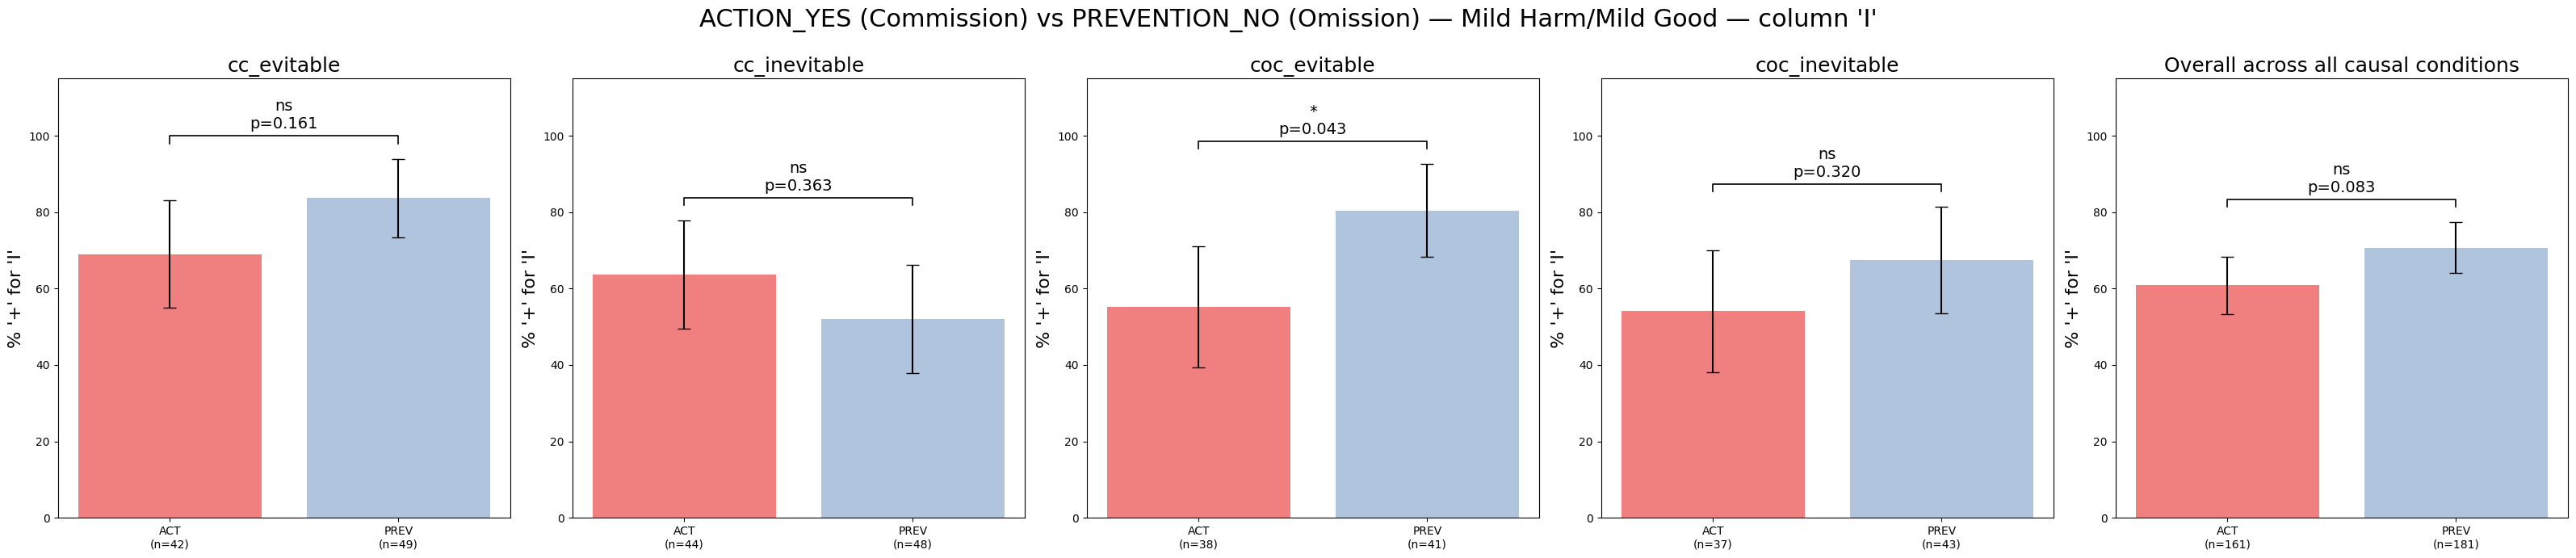

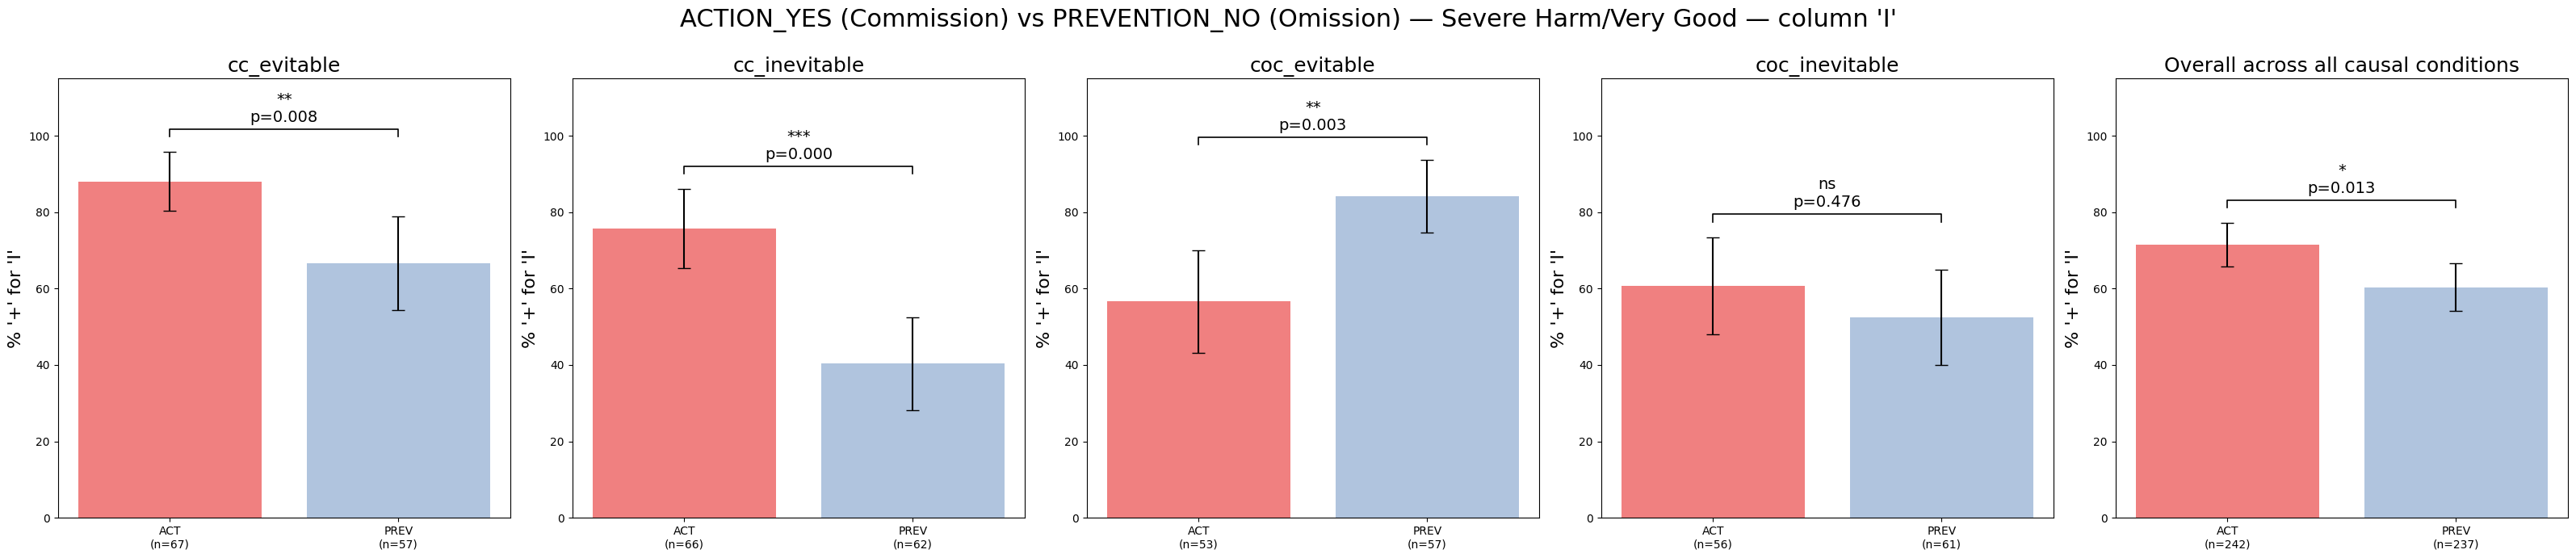

In [ ]:
create_barplots(mild_FRANKEN_df, "Mild Harm/Mild Good", column="I")
create_barplots(severe_FRANKEN_df, "Severe Harm/Very Good", column="I")

- #### **Hypothesis is partially true.** We see an expected (and significant) difference between commission and omission in 1/4 mild causal condition pairs, and 3/4 severe causal condition pairs. **Hypothesis is also overall true for severe, but not for mild.**

## Experiment 4 -- Do "severe" scenarios get events with more extreme utility scores than "mild" scenarios?
#### Comparing the utility score distributions between mild and severe counterparts of each causal conditions (also checking overall)
#### **Commonsense hypothesis =** When considering the PRIMARY HARM event's utility score, the "severe_harm_very_good" utility distributions SHOULD be more negative overall than the "mild_harm_mild_good" utility distributions.

##### **Important caveat: How do we pick one utility score to represent a scenario?**
We need to pick the utility score of one event for a scenario -- this event should be the "primary harm" event.
1. **Quantitative way to do it:** look at the utility score ascribed by the annotator to all events, pick the most negative score
    - Each identified entity gets its own utility score, so there are multiple sub-strategies:

        - **Simplest:** pick the single-most negative utility score **regardless of entity** across all events of a scenario
        - **"I"-only:** pick the single-most negative utility score **assigned to "I"** across all events of a scenario, i.e., where I (agent) was worst-affected
        - **Non-"I"-only:** pick the single-most negative utility score **not assigned to "I"** across all events of a scenario, i.e., where some patient was worst-affected

2. **Qualitative way to do it:** look at all events, pick the most salient harm event by hand, then either pick the utility score ascribed to "I" or the worst-affected non-"I" entity.

**Below, I only test/implement the Quantitative ways,** because the Qualitative hand-picking is getting annoying, AND ALSO from my older notebook analysis where I did do it (with an older version of the annotator so non-transferrable here), it yielded a non-significant difference in utility distributions anyway.

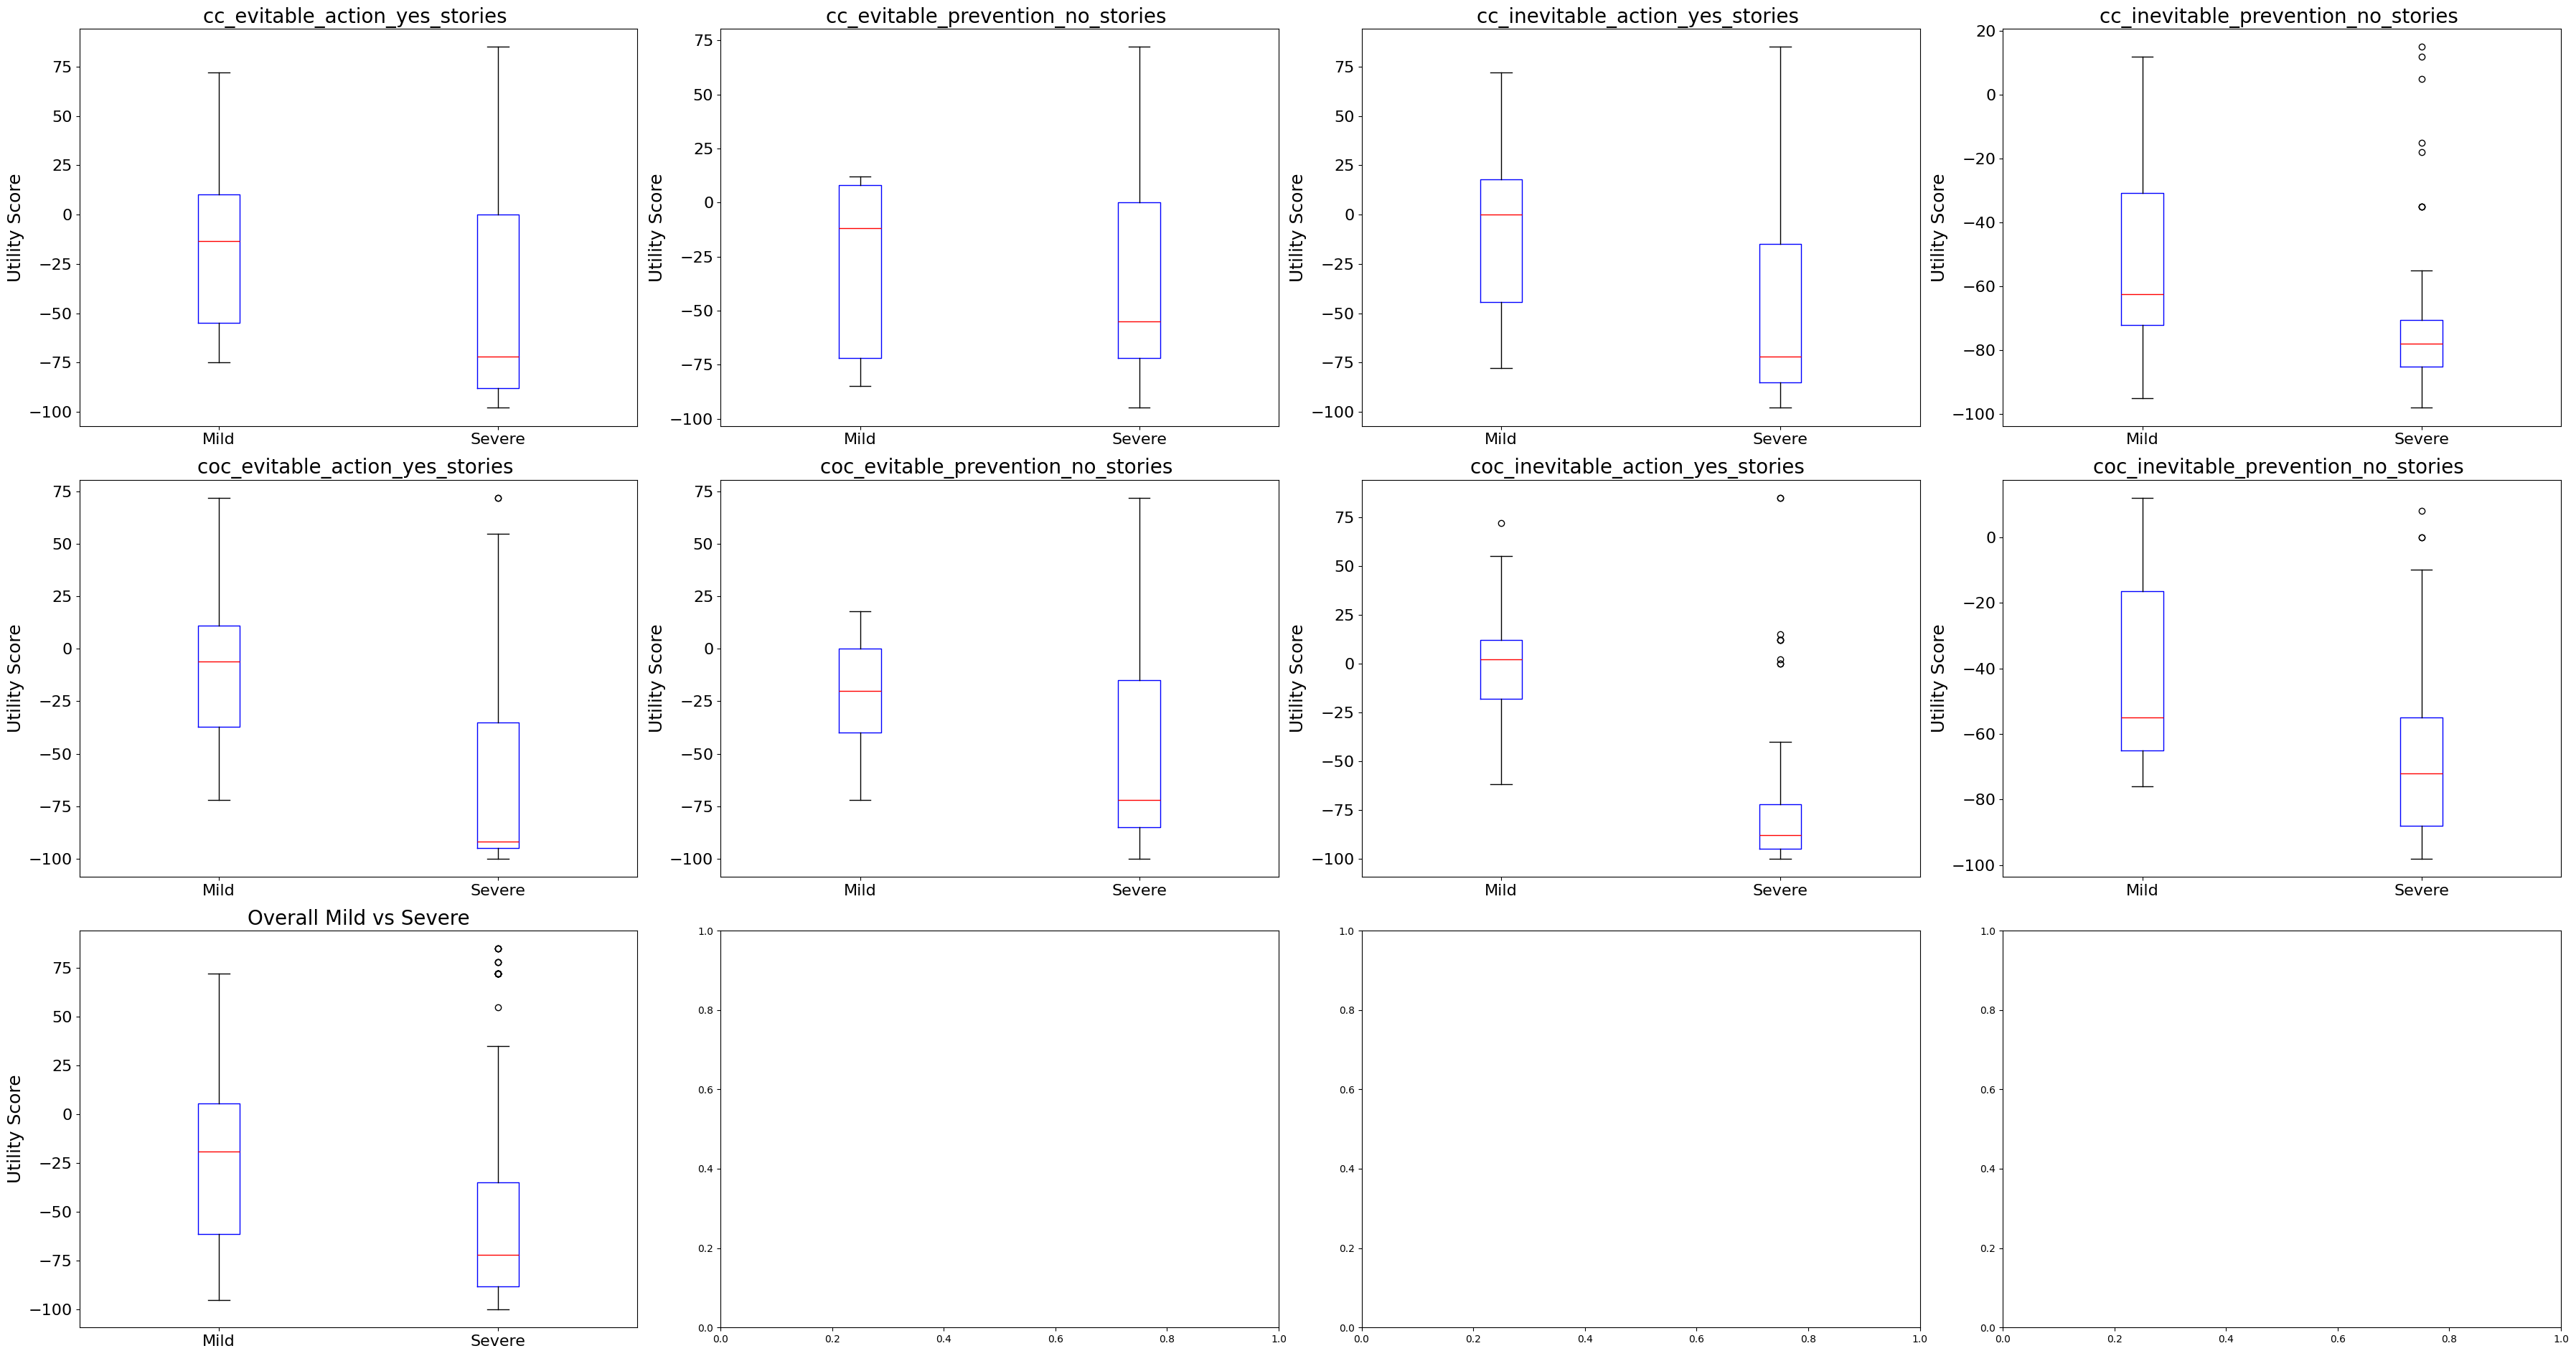

In [ ]:
def extract_utility_score(utility_dict):
    # convert the values from strings to floats
    utility_dict = {k: float(v) for k, v in utility_dict.items()}

    # # "I"-only strategy filter:
    # # keep only the key value pair where the key is "i"
    # if "i" in utility_dict:
    #     utility_dict = {"i": utility_dict["i"]}
    
    # # non-"I"-only strategy filter:
    # # remove all key value pairs where the key is "i", UNLESS there are no other key value pairs, in which case keep it
    # if len(utility_dict) > 1:
    #     utility_dict = {k: v for k, v in utility_dict.items() if k != "i"}

    # Simplest strategy, just return the minimum found utility value
    # This stays uncommented for all strategies
    return min(utility_dict.values())

def create_boxplots(df, title_suffix):
    # make 3 rows of plots, 4 plots in the first two rows and 1 overall plot in the third row
    fig, axs = plt.subplots(3, 4, figsize=(36, 19))
    axs = axs.flatten()
    # Define the causal conditions
    causal_conditions = ["cc_evitable_action_yes_stories", "cc_evitable_prevention_no_stories", "cc_inevitable_action_yes_stories", "cc_inevitable_prevention_no_stories", "coc_evitable_action_yes_stories", "coc_evitable_prevention_no_stories", "coc_inevitable_action_yes_stories", "coc_inevitable_prevention_no_stories"]
    # Loop through the causal conditions and create boxplots
    for i, causal_condition in enumerate(causal_conditions):
        mild_data = df[(df["causal_condition"] == causal_condition) & (df["intensity"] == "mild_harm_mild_good")]["utility"].apply(extract_utility_score)
        severe_data = df[(df["causal_condition"] == causal_condition) & (df["intensity"] == "severe_harm_very_good")]["utility"].apply(extract_utility_score)
        axs[i].boxplot([mild_data.dropna(), severe_data.dropna()], tick_labels=["Mild", "Severe"], patch_artist=False, boxprops=dict(color='blue'), medianprops=dict(color='red'))
        axs[i].tick_params(axis='x', labelsize=16)
        axs[i].set_title(f"{causal_condition} {title_suffix}", fontsize=20)
        axs[i].set_ylabel("Utility Score", fontsize=18)
        axs[i].tick_params(axis='y', labelsize=16)
    # Create the ninth boxplot for overall mild vs severe
    overall_mild_data = df[df["intensity"] == "mild_harm_mild_good"]["utility"].apply(extract_utility_score)
    overall_severe_data = df[df["intensity"] == "severe_harm_very_good"]["utility"].apply(extract_utility_score)
    axs[8].boxplot([overall_mild_data.dropna(), overall_severe_data.dropna()], tick_labels=["Mild", "Severe"], patch_artist=False, boxprops=dict(color='blue'), medianprops=dict(color='red'))
    axs[8].set_title(f"Overall Mild vs Severe", fontsize=20)
    axs[8].set_ylabel("Utility Score", fontsize=18)
    axs[8].tick_params(axis='y', labelsize=16)
    axs[8].tick_params(axis='x', labelsize=16)

    plt.tight_layout()
    plt.show()

create_boxplots(all_FRANKEN_df, "")

#### The median utility score is the red line, and the boxes show the interquartile range, with the whiskers showing the rest of the distribution. The circle points show the outliers.

- #### The utility scores look more negative-shifted in general for severe scenarios in general.

- #### **So our hypothesis comes true** -- it tell us that the "severe" scenarios' worst scores are more negative than "mild" scenarios' worst scores. (So "severe_harm" is indeed more severe than "mild_harm"). 

    - ##### Is "_very_good" indeed more good than "_mild_good" though? We don't know that part. We could know if we compared the most positive event utility scores b/w severe and mild scenarios instead, but it doesn't really matter as a thing to check. I suspect it is true.

#### - Is our severe utility distribution **statistically signficantly** more negative than mild distribution though? **Run a one-sided t-test for this:**

In [ ]:
# now I want to see if there are significant differences between the utility distributions of the mild and severe conditions above -- T-TEST TIME!
def perform_t_tests(df):
    causal_conditions = ["cc_evitable_action_yes_stories", "cc_evitable_prevention_no_stories", "cc_inevitable_action_yes_stories", "cc_inevitable_prevention_no_stories", "coc_evitable_action_yes_stories", "coc_evitable_prevention_no_stories", "coc_inevitable_action_yes_stories", "coc_inevitable_prevention_no_stories"]
    results = {}
    for causal_condition in causal_conditions:
        mild_data = df[(df["causal_condition"] == causal_condition) & (df["intensity"] == "mild_harm_mild_good")]["utility"].apply(extract_utility_score).dropna()
        severe_data = df[(df["causal_condition"] == causal_condition) & (df["intensity"] == "severe_harm_very_good")]["utility"].apply(extract_utility_score).dropna()
        # t_stat, p_value = ttest_ind(mild_data, severe_data, equal_var=False) # two-tailed test
        t_stat, p_value = ttest_ind(severe_data, mild_data, alternative="less") # one-tailed test to see if severe is less than mild
        results[causal_condition] = {"t_stat": t_stat, "p_value": p_value}
    # Overall comparison
    overall_mild_data = df[df["intensity"] == "mild_harm_mild_good"]["utility"].apply(extract_utility_score).dropna()
    overall_severe_data = df[df["intensity"] == "severe_harm_very_good"]["utility"].apply(extract_utility_score).dropna()
    # t_stat, p_value = ttest_ind(overall_mild_data, overall_severe_data, equal_var=False)
    t_stat, p_value = ttest_ind(overall_severe_data, overall_mild_data, alternative="less") # one-tailed test to see if severe is less than mild
    results["overall"] = {"t_stat": t_stat, "p_value": p_value}
    return results

t_test_results = perform_t_tests(all_FRANKEN_df)
print("T-test results comparing utility scores between mild and severe conditions:")
pprint.pprint(t_test_results)

T-test results comparing utility scores between mild and severe conditions:
{'cc_evitable_action_yes_stories': {'p_value': np.float64(0.004783778597584393),
                                    't_stat': np.float64(-2.638578871880066)},
 'cc_evitable_prevention_no_stories': {'p_value': np.float64(0.052026113831155206),
                                       't_stat': np.float64(-1.639876677809864)},
 'cc_inevitable_action_yes_stories': {'p_value': np.float64(2.4262915885414675e-05),
                                      't_stat': np.float64(-4.233308022051441)},
 'cc_inevitable_prevention_no_stories': {'p_value': np.float64(2.400247938690451e-05),
                                         't_stat': np.float64(-4.236138001237201)},
 'coc_evitable_action_yes_stories': {'p_value': np.float64(3.7640597262104173e-06),
                                     't_stat': np.float64(-4.757322749931924)},
 'coc_evitable_prevention_no_stories': {'p_value': np.float64(0.00013438095583302763),
          

#### Alright! t-stat being negative means that severe scores are indeed more negative than mild. And look at the p-values:

- #### If I use the **simplest** strategy (shown above), i.e. any entity is affected the worst, **then the statistical significance exists within 7/8 causal conditions (just one is p=0.052) AND for overall too.** All 9 t-stats are negative. (8 causal conditions + 1 overall)

- #### If I use the **non-"I"-only** strategy (not shown but easily runnable by you), i.e. some patient is affected the worst, **then the statistical significance exists within 5/8 causal conditions AND for overall too.** All 9 t-stats are negative.

- #### If I use the **"I"-only** strategy (not shown but easily runnable by you), i.e. agent is affected the worst, **then the statistical significance exists within 3/8 causal conditions (really only 2/8, one is p=0.0499) AND for overall too.** 8/9 t-stats are negative.

#### So, **the severe utility score distributions are (basically) always statistically significantly more negative than mild counterpart**, no matter what (quantitative) heuristic I use to pick out the utility score representative of a scenario.